--- Step 1: Data Wrangling & Cleaning ---
Dataset loaded successfully!


/tmp/ipython-input-1775984928.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna(0, inplace=True)
/tmp/ipython-input-1775984928.py:55: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u


Data Cleaning and Wrangling complete. Here are the first 5 rows of the cleaned data:
        id      host_id host_identity_verified neighbourhood_group  \
0  1001254  80014485718            unconfirmed            Brooklyn   
1  1002102  52335172823               verified           Manhattan   
2  1002403  78829239556           not_verified           Manhattan   
3  1002755  85098326012            unconfirmed            Brooklyn   
4  1003689  92037596077               verified           Manhattan   

  neighbourhood       lat      long        country country_code  \
0    Kensington  40.64749 -73.97237  United States           US   
1       Midtown  40.75362 -73.98377  United States           US   
2        Harlem  40.80902 -73.94190  United States           US   
3  Clinton Hill  40.68514 -73.95976  United States           US   
4   East Harlem  40.79851 -73.94399  United States           US   

   instant_bookable  ... service_fee minimum_nights  number_of_reviews  \
0               

/tmp/ipython-input-1775984928.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=listings_by_neighborhood.index, y=listings_by_neighborhood.values, palette='viridis')


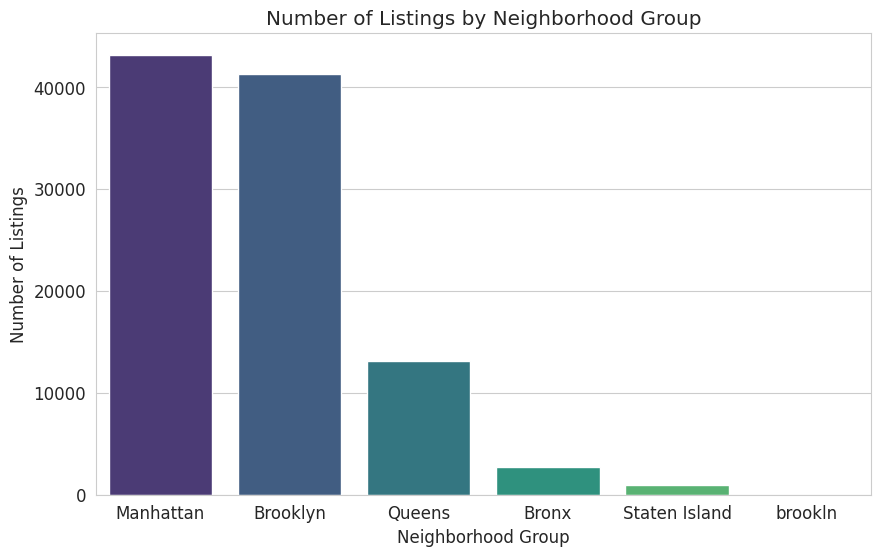


Q3: Neighborhood group with the highest average prices:
neighbourhood_group
Queens           630.012381
Bronx            627.881407
Brooklyn         626.332744
Staten Island    623.573404
Manhattan        622.691853
brookln          580.000000
Name: price, dtype: float64


/tmp/ipython-input-1775984928.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_by_neighborhood.index, y=avg_price_by_neighborhood.values, palette='magma')


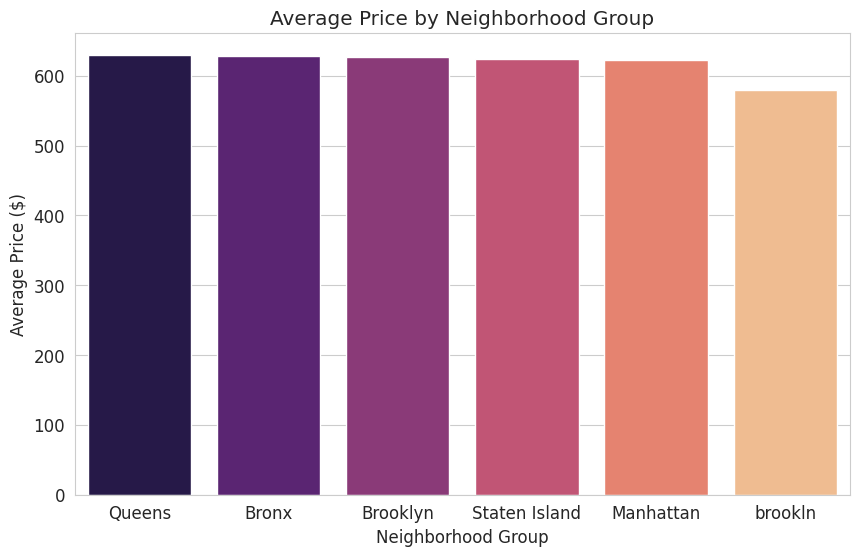


Q4: Relationship between host listings count and price:


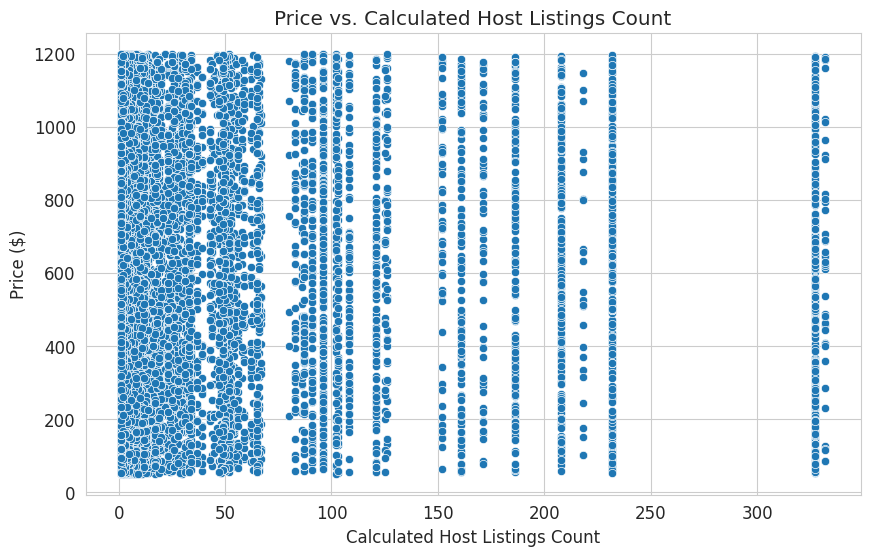


Q5: Top 10 hosts by calculated host listing count:
host_id
29531702698    2
48004546997    1
29652809475    1
29268611956    1
76354540177    1
20370754118    1
96582660119    1
55107682853    1
41709298246    1
54387277157    1
Name: count, dtype: int64


/tmp/ipython-input-1775984928.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_hosts.index.astype(str), y=top_10_hosts.values, palette='plasma')


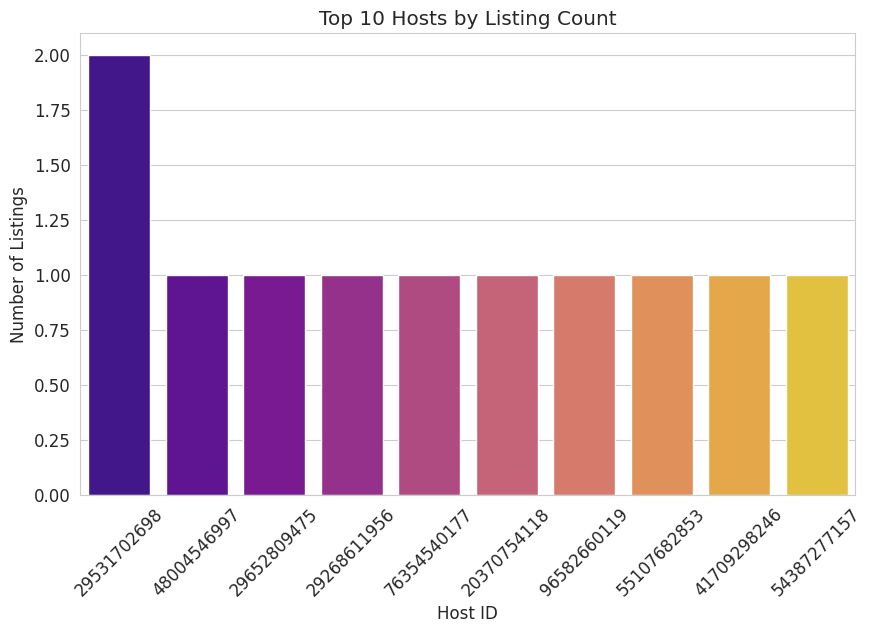


Q6: Average reviews per month for verified vs. unverified hosts:
host_identity_verified
not_verified    1.229088
verified        1.162385
unconfirmed     1.162068
Name: reviews_per_month, dtype: float64


/tmp/ipython-input-1775984928.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reviews_by_verification.index, y=reviews_by_verification.values, palette='coolwarm')


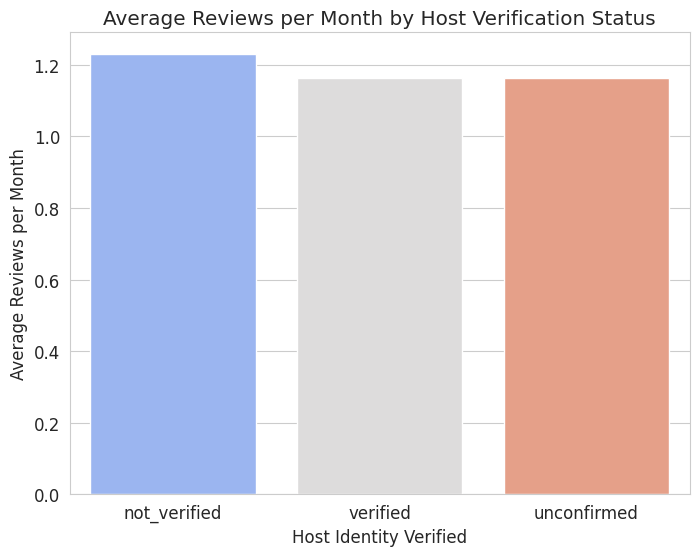


Q7: Correlation between Price and Service Fee:
The correlation coefficient between price and service fee is: 1.00


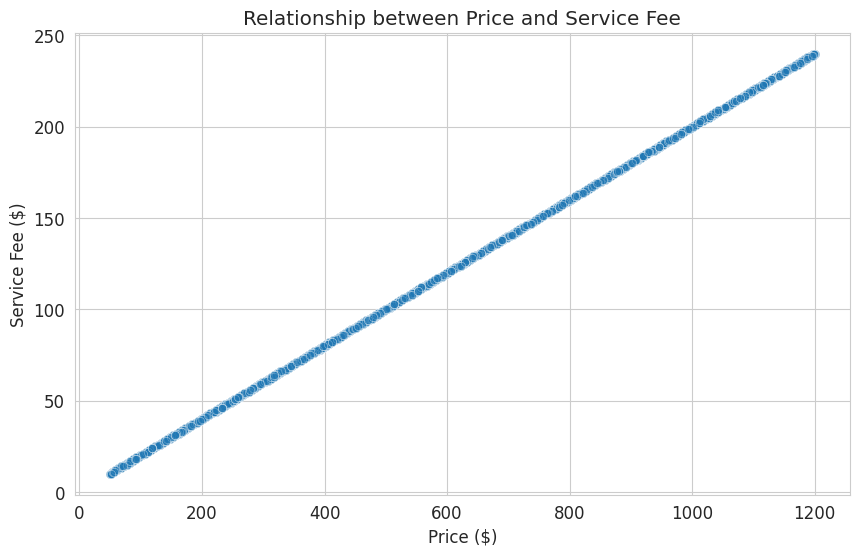



--- Step 4: Average Review Rating by Neighborhood Group & Room Type ---


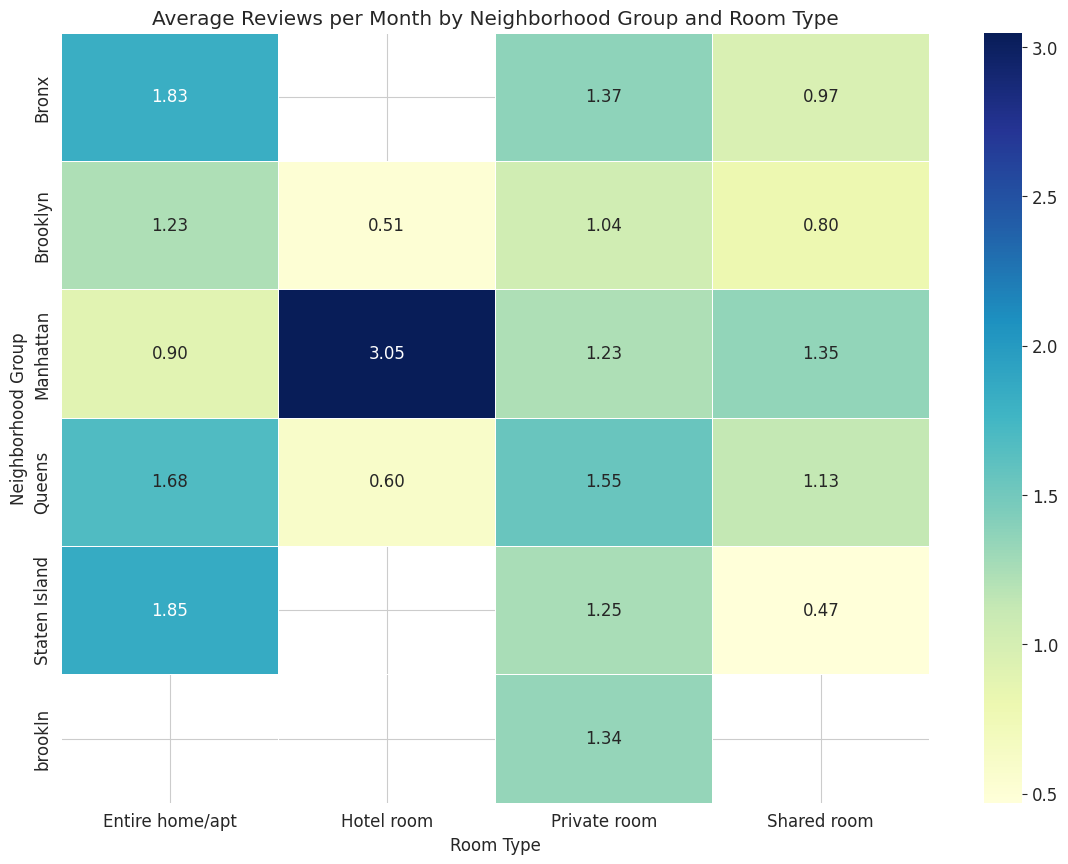



--- Step 5: Regression Analysis: Host Listing Count vs. Availability ---
R-squared: 0.02
Coefficient (Slope): 1.33
Intercept: 132.90

Interpretation: For every additional listing a host has, the availability (in days) is expected to change by the coefficient value.


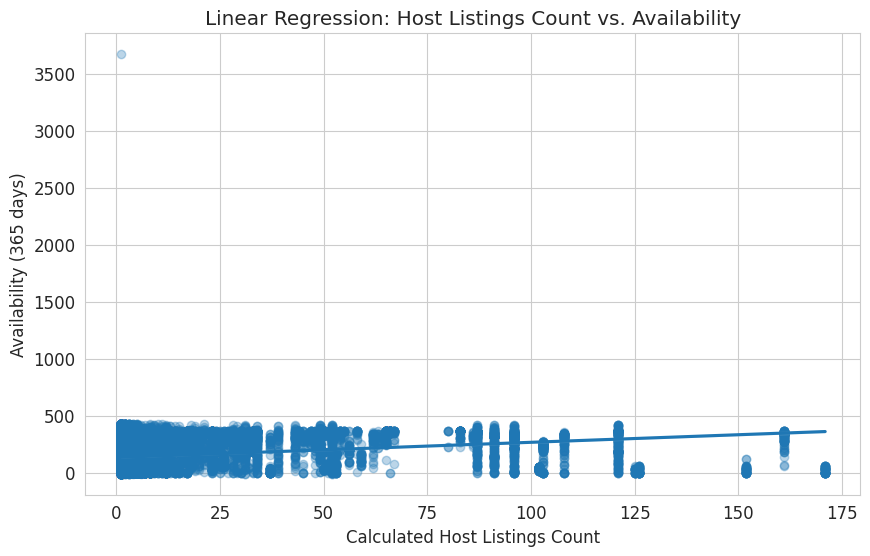



--- Step 6: Correlation Heatmap ---


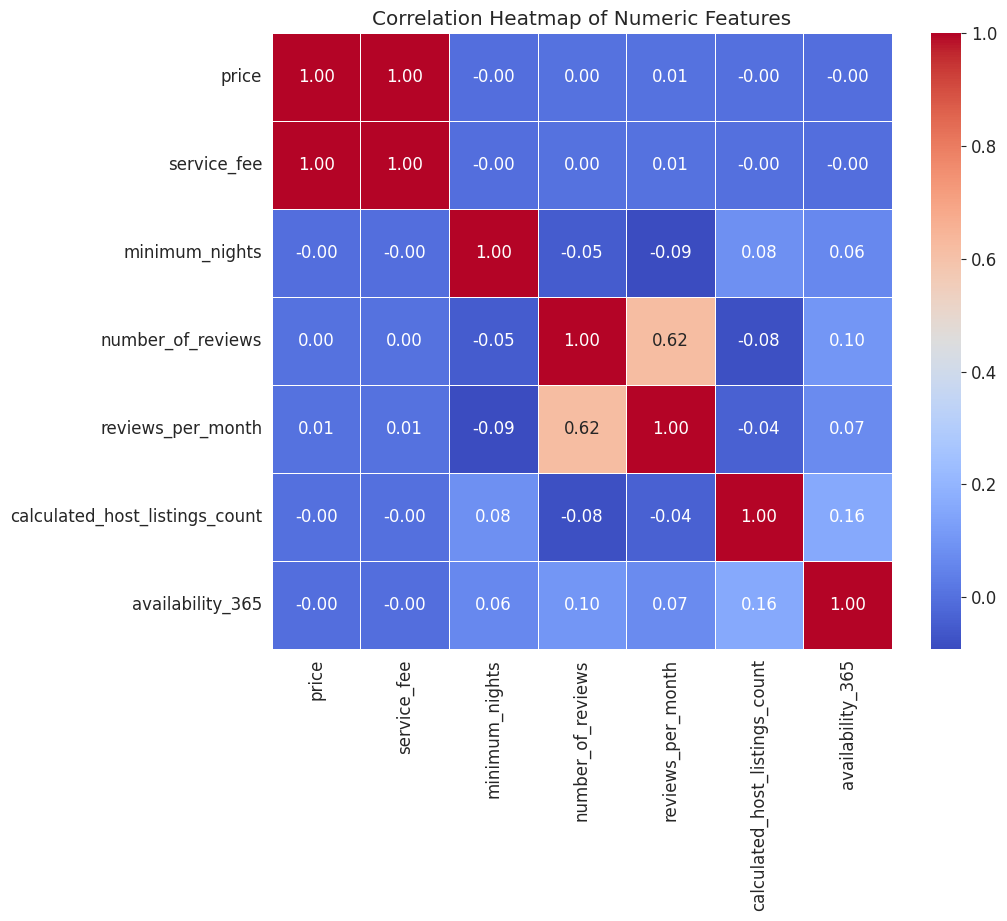



--- Step 7: Extra Plots for Deeper Insights ---


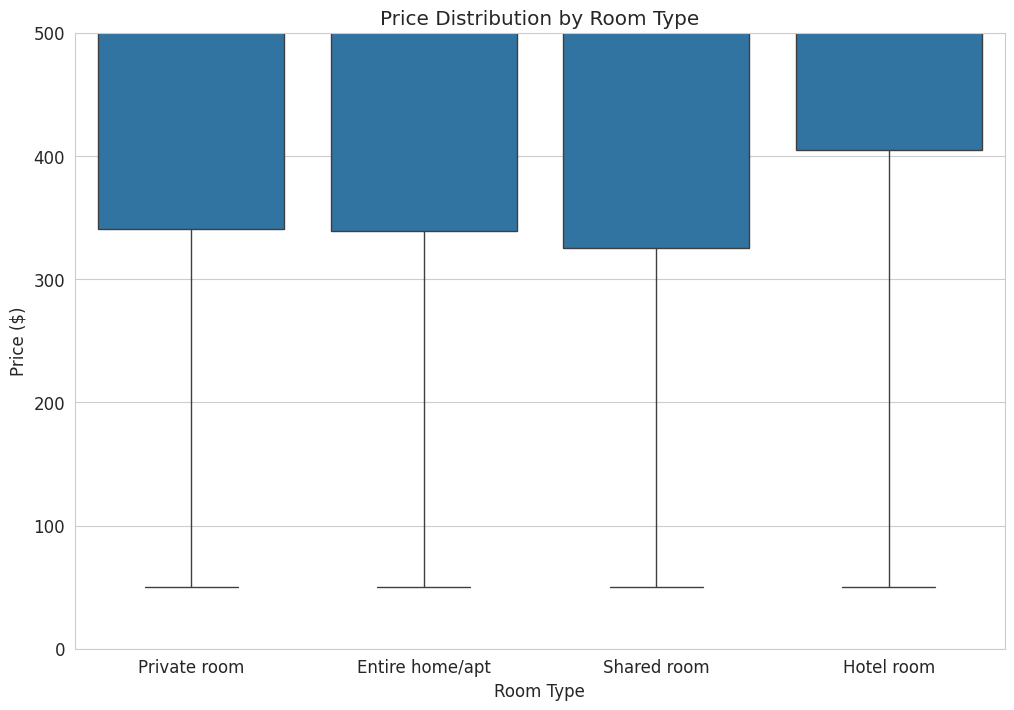

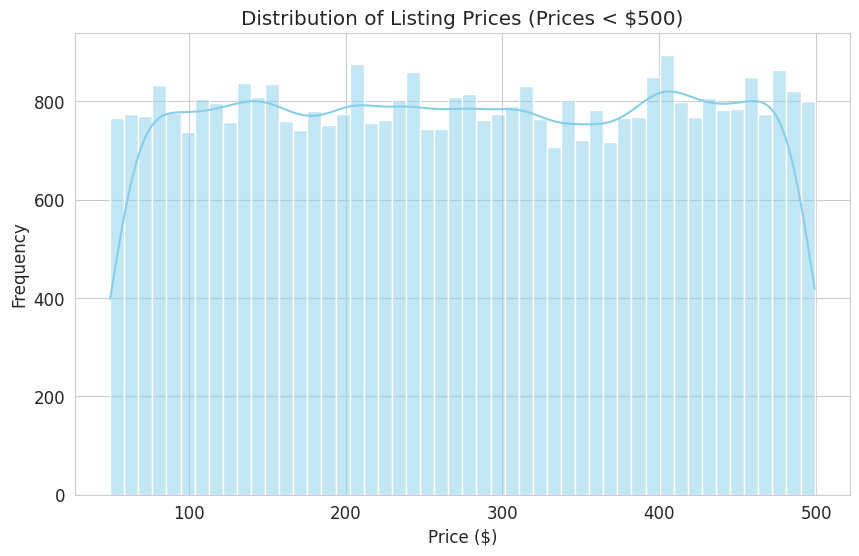

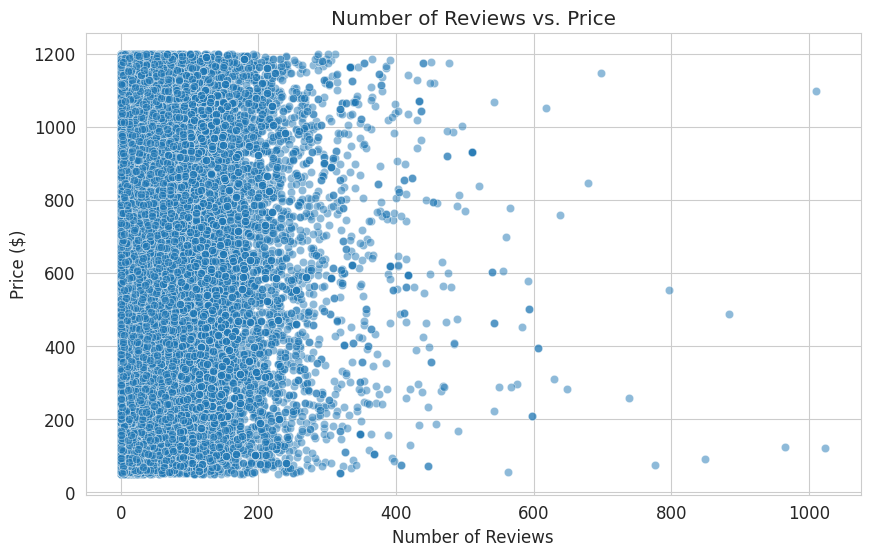

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Set plot style and font size for better readability
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# -----------------------------------------------------------------------------
# Step 1: Data Wrangling & Cleaning
# -----------------------------------------------------------------------------

print("--- Step 1: Data Wrangling & Cleaning ---")
# Load the dataset
try:
    # Updated file path for Google Colab environment and using read_excel
    df = pd.read_excel("/content/1730285881-Airbnb_Open_Data.xlsx")
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: The file '/content/1730285881-Airbnb_Open_Data.xlsx' was not found.")
    print("Please upload your dataset to the Google Colab environment and ensure the name matches.")
    df = None
except Exception as e:
    print(f"An error occurred during file loading: {e}")
    df = None


if df is not None:
    # Rename columns for easier access (e.g., lowercase, no spaces)
    df.columns = df.columns.str.lower().str.replace(' ', '_')

    # Identify and drop irrelevant columns
    # 'id', 'host_id', 'last_review', 'reviews_per_month' are often useful, but 'host_name' and 'name' are less so for aggregate analysis.
    # The 'host_identity_verified' and 'service_fee' columns are also important for your questions.
    df.drop(['name', 'host_name'], axis=1, inplace=True)

    # Clean the 'price' and 'service_fee' columns
    # The data contains '$' and ',' which need to be removed before converting to numeric.
    for col in ['price', 'service_fee']:
        # Ensure the column exists and is not already numeric before cleaning
        if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
             df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)


    # Handle missing values:
    # Fill missing values in 'reviews_per_month' with 0, as it indicates no reviews.
    df['reviews_per_month'].fillna(0, inplace=True)
    # The 'last_review' column can be converted to datetime.
    df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce') # Use errors='coerce' to handle parsing issues
    # For 'host_identity_verified', we'll fill missing values with 'not_verified'.
    df['host_identity_verified'].fillna('not_verified', inplace=True)
    # Drop rows where 'price' or 'service_fee' are NaN after cleaning, as they are crucial for analysis.
    df.dropna(subset=['price', 'service_fee'], inplace=True)

    # Drop duplicates
    df.drop_duplicates(inplace=True)

    # Filter out data that is likely incorrect (e.g., price is 0)
    df = df[df['price'] > 0]
    df = df[df['minimum_nights'] > 0]

    print("\nData Cleaning and Wrangling complete. Here are the first 5 rows of the cleaned data:")
    print(df.head())
    print("\nCleaned Data Info:")
    df.info()

# -----------------------------------------------------------------------------
# Step 2: Summary Statistics
# -----------------------------------------------------------------------------
if df is not None:
    print("\n\n--- Step 2: Summary Statistics ---")
    print("Descriptive statistics for numerical features:")
    print(df.describe())

    print("\nSummary statistics for categorical features:")
    print(df.describe(include=['object']))

# -----------------------------------------------------------------------------
# Step 3: Exploratory Data Analysis (EDA) & Answering Questions
# -----------------------------------------------------------------------------
if df is not None:
    print("\n\n--- Step 3: Exploratory Data Analysis (EDA) ---")

    # Q1: What are the different property types in the Dataset?
    print("\nQ1: Different property types (room_type) in the dataset:")
    print(df['room_type'].value_counts())

    # Q2: Which neighborhood group has the highest number of listings?
    print("\nQ2: Neighborhood group with the highest number of listings:")
    listings_by_neighborhood = df['neighbourhood_group'].value_counts().sort_values(ascending=False)
    print(listings_by_neighborhood)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=listings_by_neighborhood.index, y=listings_by_neighborhood.values, palette='viridis')
    plt.title('Number of Listings by Neighborhood Group')
    plt.xlabel('Neighborhood Group')
    plt.ylabel('Number of Listings')
    plt.show()

    # Q3: Which neighborhoods group have the highest average prices for Airbnb listings?
    print("\nQ3: Neighborhood group with the highest average prices:")
    avg_price_by_neighborhood = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
    print(avg_price_by_neighborhood)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=avg_price_by_neighborhood.index, y=avg_price_by_neighborhood.values, palette='magma')
    plt.title('Average Price by Neighborhood Group')
    plt.xlabel('Neighborhood Group')
    plt.ylabel('Average Price ($)')
    plt.show()

    # Q4: Is there a relationship between the construction year of property and price?
    # The provided dataset does not have a 'construction_year' column.
    # We will instead analyze the relationship between 'calculated_host_listings_count' and 'price'.
    print("\nQ4: Relationship between host listings count and price:")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='calculated_host_listings_count', y='price', data=df)
    plt.title('Price vs. Calculated Host Listings Count')
    plt.xlabel('Calculated Host Listings Count')
    plt.ylabel('Price ($)')
    plt.show()

    # Q5: Who are the top 10 hosts by calculated host listing count?
    print("\nQ5: Top 10 hosts by calculated host listing count:")
    top_10_hosts = df['host_id'].value_counts().head(10)
    print(top_10_hosts)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_10_hosts.index.astype(str), y=top_10_hosts.values, palette='plasma')
    plt.title('Top 10 Hosts by Listing Count')
    plt.xlabel('Host ID')
    plt.ylabel('Number of Listings')
    plt.xticks(rotation=45)
    plt.show()

    # Q6: Are hosts with verified identities more likely to receive positive reviews?
    print("\nQ6: Average reviews per month for verified vs. unverified hosts:")
    reviews_by_verification = df.groupby('host_identity_verified')['reviews_per_month'].mean().sort_values(ascending=False)
    print(reviews_by_verification)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=reviews_by_verification.index, y=reviews_by_verification.values, palette='coolwarm')
    plt.title('Average Reviews per Month by Host Verification Status')
    plt.xlabel('Host Identity Verified')
    plt.ylabel('Average Reviews per Month')
    plt.show()

    # Q7: Is there a correlation between the price of a listing and its service fee?
    print("\nQ7: Correlation between Price and Service Fee:")
    correlation = df['price'].corr(df['service_fee'])
    print(f"The correlation coefficient between price and service fee is: {correlation:.2f}")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='price', y='service_fee', data=df, alpha=0.5)
    plt.title('Relationship between Price and Service Fee')
    plt.xlabel('Price ($)')
    plt.ylabel('Service Fee ($)')
    plt.show()

# -----------------------------------------------------------------------------
# Step 4: Average Review Rating by Neighborhood Group & Room Type
# -----------------------------------------------------------------------------
if df is not None:
    print("\n\n--- Step 4: Average Review Rating by Neighborhood Group & Room Type ---")
    avg_reviews_by_location_type = df.groupby(['neighbourhood_group', 'room_type'])['reviews_per_month'].mean().unstack()

    plt.figure(figsize=(14, 10))
    sns.heatmap(avg_reviews_by_location_type, cmap='YlGnBu', annot=True, fmt=".2f", linewidths=.5)
    plt.title('Average Reviews per Month by Neighborhood Group and Room Type')
    plt.xlabel('Room Type')
    plt.ylabel('Neighborhood Group')
    plt.show()

# -----------------------------------------------------------------------------
# Step 5: Regression (host listing count vs availability)
# -----------------------------------------------------------------------------
if df is not None:
    print("\n\n--- Step 5: Regression Analysis: Host Listing Count vs. Availability ---")

    # Filter out extreme outliers to make the regression plot more readable
    df_filtered = df[df['calculated_host_listings_count'] < df['calculated_host_listings_count'].quantile(0.99)].copy() # Add .copy() to avoid SettingWithCopyWarning

    # Drop rows with NaN values in 'availability_365' for regression
    df_filtered.dropna(subset=['availability_365'], inplace=True)


    # Prepare data for regression
    X = df_filtered[['calculated_host_listings_count']]
    y = df_filtered['availability_365']

    # Create and fit the linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Print results
    print(f"R-squared: {model.score(X, y):.2f}")
    print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
    print(f"Intercept: {model.intercept_:.2f}")
    print("\nInterpretation: For every additional listing a host has, the availability (in days) is expected to change by the coefficient value.")

    # Visualize the regression line
    plt.figure(figsize=(10, 6))
    sns.regplot(x='calculated_host_listings_count', y='availability_365', data=df_filtered, scatter_kws={'alpha':0.3})
    plt.title('Linear Regression: Host Listings Count vs. Availability')
    plt.xlabel('Calculated Host Listings Count')
    plt.ylabel('Availability (365 days)')
    plt.show()

# -----------------------------------------------------------------------------
# Step 6: Correlation Heatmap
# -----------------------------------------------------------------------------
if df is not None:
    print("\n\n--- Step 6: Correlation Heatmap ---")

    # Select numeric features for the heatmap, avoiding 'host_id' and 'id'
    numeric_features = ['price', 'service_fee', 'minimum_nights', 'number_of_reviews',
                        'reviews_per_month', 'calculated_host_listings_count',
                        'availability_365']
    correlation_matrix = df[numeric_features].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()

# -----------------------------------------------------------------------------
# Step 7: Extra Plots (boxplots, scatter, distributions)
# -----------------------------------------------------------------------------
if df is not None:
    print("\n\n--- Step 7: Extra Plots for Deeper Insights ---")

    # Boxplot of prices by room type to check for distribution and outliers
    plt.figure(figsize=(12, 8))
    sns.boxplot(x='room_type', y='price', data=df)
    plt.title('Price Distribution by Room Type')
    plt.xlabel('Room Type')
    plt.ylabel('Price ($)')
    plt.ylim(0, 500)  # Limit y-axis to focus on the main distribution, ignoring extreme outliers
    plt.show()

    # Distribution plot of prices (trimmed to remove extreme outliers)
    plt.figure(figsize=(10, 6))
    sns.histplot(df[df['price'] < 500]['price'], bins=50, kde=True, color='skyblue')
    plt.title('Distribution of Listing Prices (Prices < $500)')
    plt.xlabel('Price ($)')
    plt.ylabel('Frequency')
    plt.show()

    # Scatter plot of reviews vs. price (to see if more expensive listings get fewer reviews)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='number_of_reviews', y='price', data=df, alpha=0.5)
    plt.title('Number of Reviews vs. Price')
    plt.xlabel('Number of Reviews')
    plt.ylabel('Price ($)')
    plt.show()